In [57]:
#自动重载外部文件的更新
%load_ext autoreload
%autoreload 2

# 添加项目路径至path
import os
import sys
currentPath = os.path.join(os.getcwd(),"machinelearningIntro","机器学习实践/大作业_一卡通数据")
sys.path.append(currentPath)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
import seaborn as sns

In [59]:
%%time
datadir = r"D:\PythonEx\machinelearningIntro\机器学习实践\大作业_一卡通数据\output_data\cluster_data.xlsx"
df = pd.read_excel(datadir,index_col="CardNo")

CPU times: total: 359 ms
Wall time: 359 ms


In [60]:
df = df.drop("Sex_bin",axis=1)

In [61]:
df.head()

,MoneySum,ConsumeCount,MoneyMean,MoneyStd,Surplus,CanteenMoneySum,CanteenMoneyMean,meal_time_breakfast,meal_time_dinner,meal_time_lunch,meal_time_not_meal_time,DepositCount,DepositMean
CardNo,,,,,,,,,,,,,
180001,158.0,31,5.096774,3.026382,25.845161,158.0,5.096774,13.0,8.0,8.0,2.0,3.0,53.333333
180002,113.4,40,2.835000,2.264390,65.210000,97.4,2.563158,10.0,14.0,14.0,0.0,1.0,100.000000
180004,555.0,91,6.098901,2.795095,64.617582,530.0,6.309524,12.0,36.0,36.0,0.0,4.0,125.000000
180005,185.1,35,5.288571,3.229803,81.665714,166.9,5.563333,0.0,17.0,13.0,0.0,1.0,100.000000
180006,85.7,20,4.285000,3.718131,41.565000,81.7,4.300000,2.0,9.0,8.0,0.0,NaN,NaN


In [62]:
corr = df.corr()
corr

,MoneySum,ConsumeCount,MoneyMean,MoneyStd,Surplus,CanteenMoneySum,CanteenMoneyMean,meal_time_breakfast,meal_time_dinner,meal_time_lunch,meal_time_not_meal_time,DepositCount,DepositMean
MoneySum,1.000000,0.757212,0.140966,0.263738,0.372902,0.976440,0.111630,0.431754,0.673575,0.616126,0.304670,0.645130,0.314918
ConsumeCount,0.757212,1.000000,-0.418803,-0.191884,0.263076,0.755429,-0.445176,0.652720,0.877739,0.878050,0.358664,0.504197,0.175682
MoneyMean,0.140966,-0.418803,1.000000,0.579217,0.109477,0.098175,0.981029,-0.406875,-0.321014,-0.434028,-0.122924,0.046052,0.132136
MoneyStd,0.263738,-0.191884,0.579217,1.000000,0.184522,0.255006,0.564207,-0.178492,-0.169858,-0.174254,-0.054131,0.069628,0.149752
Surplus,0.372902,0.263076,0.109477,0.184522,1.000000,0.365108,0.085244,0.112793,0.225019,0.260496,0.057665,-0.173855,0.781737
CanteenMoneySum,0.976440,0.755429,0.098175,0.255006,0.365108,1.000000,0.081216,0.481593,0.694428,0.639446,0.336163,0.618380,0.312871
CanteenMoneyMean,0.111630,-0.445176,0.981029,0.564207,0.085244,0.081216,1.000000,-0.416373,-0.327445,-0.439276,-0.124273,0.033282,0.118357
meal_time_breakfast,0.431754,0.652720,-0.406875,-0.178492,0.112793,0.481593,-0.416373,1.000000,0.401348,0.382759,0.247728,0.304256,0.065739
meal_time_dinner,0.673575,0.877739,-0.321014,-0.169858,0.225019,0.694428,-0.327445,0.401348,1.000000,0.741687,0.275393,0.441361,0.170695
meal_time_lunch,0.616126,0.878050,-0.434028,-0.174254,0.260496,0.639446,-0.439276,0.382759,0.741687,1.000000,0.215655,0.366933,0.161237


In [63]:
df["DepositMean"].describe()

count    3028.000000
mean      119.401249
std        48.600848
min        50.000000
25%        93.333333
50%       100.000000
75%       145.000000
max       500.000000
Name: DepositMean, dtype: float64

In [64]:
df.shape

(3199, 13)

In [65]:
df = df.fillna(0)

# 数据标准化

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df)
x_std = scaler.transform(df)
print(f"平均值：{scaler.mean_}, 标准差：{scaler.var_}")
x_std

平均值：[264.74419819  68.3651141    4.20123351   2.7955629   71.50680924
 237.96674898   4.24878728  14.8918412   19.61144108  25.34917162
   1.96123789   2.49546733 113.01875043], 标准差：[1.80102374e+04 1.36940342e+03 2.10278911e+00 6.74810718e-01
 1.51255127e+03 1.56845643e+04 2.55847713e+00 1.40572859e+02
 1.95719919e+02 2.51045632e+02 9.63463379e+00 1.82797258e+00
 2.95638499e+03]


array([[-0.79539812, -1.00971919,  0.61757181, ...,  0.01248791,
         0.37316805, -1.0977103 ],
       [-1.1277324 , -0.76651177, -0.94216523, ..., -0.63184808,
        -1.10609414, -0.23943565],
       [ 2.16282405,  0.61166356,  1.3086463 , ..., -0.63184808,
         1.11279915,  0.22035435],
       ...,
       [ 0.53170356, -0.09093563,  0.66859936, ..., -0.63184808,
         0.37316805, -0.23943565],
       [-0.16873191, -0.52330436,  0.51002205, ..., -0.30968008,
        -0.36646305,  1.13993433],
       [-0.47126043,  0.31441005, -1.16025369, ...,  0.01248791,
        -0.36646305, -0.42335164]])

# PCA

In [67]:
from sklearn.decomposition import PCA

In [68]:
pca = PCA(n_components = 10)
newX = pca.fit_transform(x_std)
print(pca.explained_variance_ratio_)
print(newX.shape)

[0.41361117 0.22761453 0.11541835 0.06696753 0.05292944 0.0411311
 0.02534345 0.02263358 0.01764714 0.01142853]
(3199, 10)


# Kmeans

D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


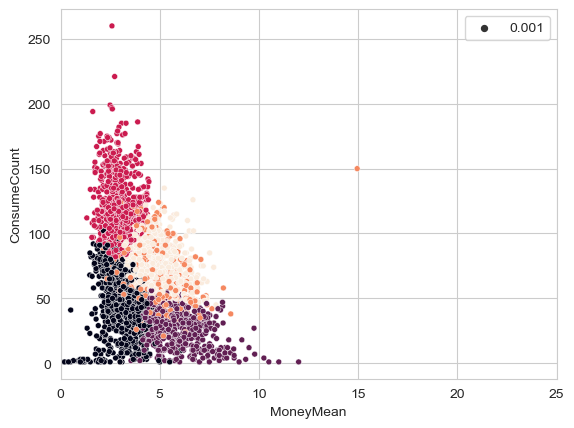

In [69]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
y_pred = KMeans(n_clusters=5, random_state=9).fit_predict(newX)
y_pred
sns.scatterplot(data=df,x = "MoneyMean", y = "ConsumeCount", c=y_pred,size=0.001)
plt.xlim((0,25))
plt.show()

In [70]:
df.groupby(y_pred).mean()

,MoneySum,ConsumeCount,MoneyMean,MoneyStd,Surplus,CanteenMoneySum,CanteenMoneyMean,meal_time_breakfast,meal_time_dinner,meal_time_lunch,meal_time_not_meal_time,DepositCount,DepositMean
0,142.967286,46.270053,3.125780,2.342826,50.974087,126.282794,3.039967,12.576203,10.364973,17.390374,1.243316,1.653743,81.514862
1,159.381817,28.290323,5.822694,3.188607,58.879478,136.171443,6.085244,4.156197,7.779287,10.521222,0.691002,1.638370,93.534239
2,349.066894,119.427273,2.936335,2.388576,76.085431,322.181379,2.892961,24.963636,37.916667,45.880303,3.374242,3.219697,119.767015
3,322.207834,70.599562,4.673929,3.073981,130.036386,289.845230,4.738486,15.006565,19.695842,26.540481,1.932166,1.842451,195.605398
4,360.359919,75.625503,4.829704,3.129145,62.145825,324.150523,4.911307,16.711409,21.981208,26.143624,2.452349,3.777181,103.415172


In [71]:
pd.DataFrame(y_pred).value_counts()

0    748
4    745
2    660
1    589
3    457
dtype: int64

D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less

Text(0.5, 1.0, '肘子图')

D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32920 (\N{CJK UNIFIED IDEOGRAPH-8098}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


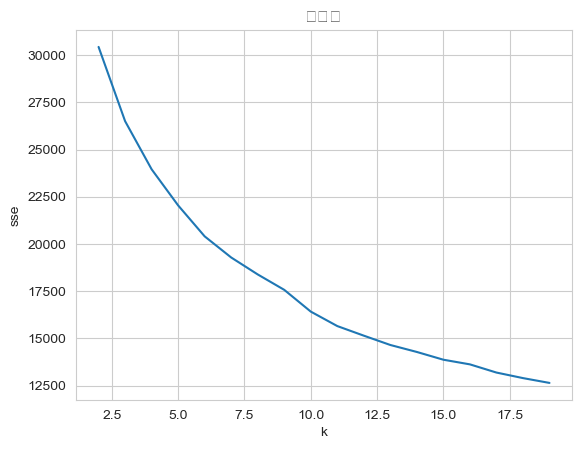

In [72]:
# 画肘子图
df1 = pd.DataFrame(columns=['k', 'sse'])

df1.columns = ['k', 'sse']

for k in range(2,20):
    model = KMeans(n_clusters=k, random_state=9)
    model.fit_predict(newX)
    sse = model.inertia_
    df1.loc[len(df1)] = [k, sse]


ax = sns.lineplot(x=df1.k, y=df1.sse)
ax.set_title("肘子图")

# Kmeoids

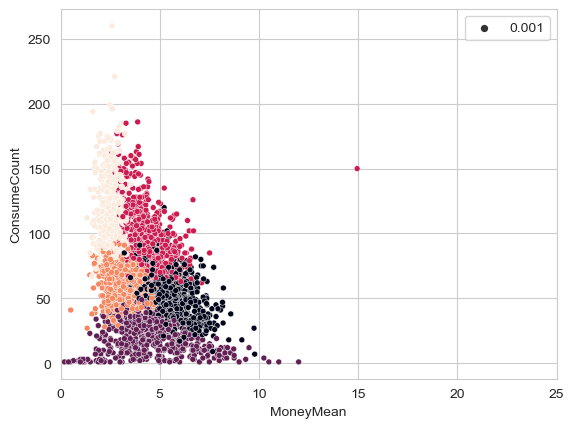

In [81]:
import matplotlib.pyplot as plt

from sklearn_extra.cluster import KMedoids

y_pred = KMedoids(n_clusters=5, random_state=9).fit_predict(newX)
y_pred
sns.scatterplot(data=df,x = "MoneyMean", y = "ConsumeCount", c=y_pred,size=0.001)
plt.xlim((0,25))
plt.show()

# AGNES

各个簇的样本数目：
0    1177
3     722
2     574
1     407
4     319
dtype: int64
聚类结果：
[1 4 0 ... 2 2 3]


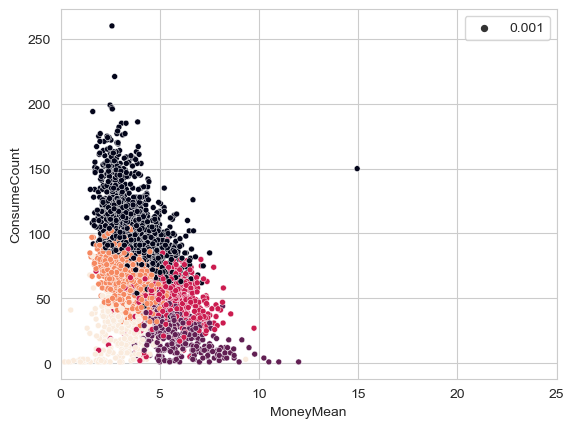

In [80]:

from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(linkage='ward', n_clusters=5)

res = clustering.fit(newX)

print("各个簇的样本数目：")
print(pd.Series(clustering.labels_).value_counts())
print("聚类结果：")
print(clustering.labels_)
sns.scatterplot(data=df,x = "MoneyMean", y = "ConsumeCount", c=clustering.labels_,size=0.001)
plt.xlim((0,25))
plt.show()

# DBSCAN

估计的聚类个数为: 4
离散点的占比：0.6880275085964364


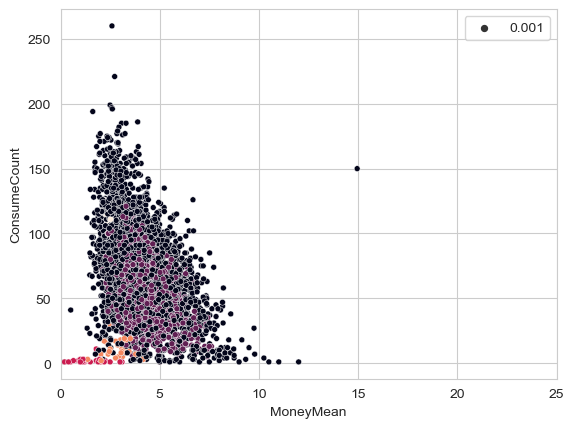

CPU times: total: 281 ms
Wall time: 276 ms


In [75]:
%%time
db = DBSCAN(eps=1.0, min_samples=10).fit(newX)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)  # 设置一个样本个数长度的全false向量
core_samples_mask[db.core_sample_indices_] = True #将核心样本部分设置为true
labels = db.labels_

# 获取聚类个数。（聚类结果中-1表示没有聚类为离散点）
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
discrete_percent = sum([1 if i == -1 else 0 for i in labels])/len(newX)

# 模型评估
print('估计的聚类个数为: %d' % n_clusters_)
print(f"离散点的占比：{discrete_percent}")
sns.scatterplot(data=df,x = "MoneyMean", y = "ConsumeCount", c=labels,size=0.001)
plt.xlim((0,25))
plt.show()

In [76]:
df.groupby(labels).mean()

,MoneySum,ConsumeCount,MoneyMean,MoneyStd,Surplus,CanteenMoneySum,CanteenMoneyMean,meal_time_breakfast,meal_time_dinner,meal_time_lunch,meal_time_not_meal_time,DepositCount,DepositMean
-1,288.185039,76.024080,4.167464,2.799170,80.757252,260.334039,4.205449,16.484780,22.069968,28.203090,2.516129,2.574284,123.788762
0,225.115011,53.724138,4.426524,2.902188,53.562535,199.243125,4.525167,11.872845,14.780172,19.877155,0.754310,2.466595,94.980693
1,2.838710,1.741935,1.698925,0.182622,3.549365,1.945161,1.088978,0.806452,0.129032,0.096774,0.096774,0.000000,0.000000
2,32.641379,11.172414,2.864805,2.168904,21.366566,29.024138,2.740289,4.137931,2.344828,3.241379,0.206897,0.000000,0.000000
3,268.009000,113.700000,2.359823,2.024138,56.787802,246.079000,2.309590,19.300000,37.300000,47.400000,2.700000,2.800000,94.583333


In [77]:
pd.DataFrame(labels).value_counts()

-1    2201
 0     928
 1      31
 2      29
 3      10
dtype: int64

<AxesSubplot:>

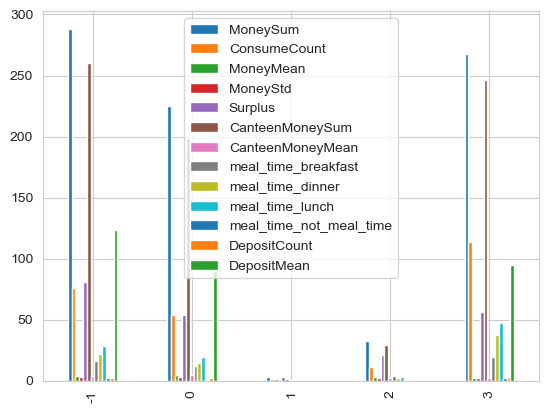

In [78]:
df.groupby(labels).mean().plot(kind = "bar")

In [79]:
df.groupby(labels)["Sex_bin"].value_counts()

KeyError: 'Column not found: Sex_bin'